In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

train = pd.read_csv('/Users/wenyuzhong/Downloads/santander-customer-satisfaction/train.csv')
test  = pd.read_csv('/Users/wenyuzhong/Downloads/santander-customer-satisfaction/test.csv')

print('Train shape:', train.shape)
print('Test shape: ', test.shape)

Train shape: (76020, 371)
Test shape:  (75818, 370)


## 1. Basic Overview

In [2]:
print('=== Data Type Distribution ===')
print(train.dtypes.value_counts())

print('\n=== Basic Statistics (first 10 features) ===')
train.describe().T.head(10)

=== Data Type Distribution ===
int64      260
float64    111
Name: count, dtype: int64

=== Basic Statistics (first 10 features) ===


,count,mean,std,min,25%,50%,75%,max
ID,76020.0,75964.050723,43781.947379,1.0,38104.75,76043.0,113748.75,151838.00
var3,76020.0,-1523.199277,39033.462364,-999999.0,2.00,2.0,2.00,238.00
var15,76020.0,33.212865,12.956486,5.0,23.00,28.0,40.00,105.00
imp_ent_var16_ult1,76020.0,86.208265,1614.757313,0.0,0.00,0.0,0.00,210000.00
imp_op_var39_comer_ult1,76020.0,72.363067,339.315831,0.0,0.00,0.0,0.00,12888.03
imp_op_var39_comer_ult3,76020.0,119.529632,546.266294,0.0,0.00,0.0,0.00,21024.81
imp_op_var40_comer_ult1,76020.0,3.559130,93.155749,0.0,0.00,0.0,0.00,8237.82
imp_op_var40_comer_ult3,76020.0,6.472698,153.737066,0.0,0.00,0.0,0.00,11073.57
imp_op_var40_efect_ult1,76020.0,0.412946,30.604864,0.0,0.00,0.0,0.00,6600.00
imp_op_var40_efect_ult3,76020.0,0.567352,36.513513,0.0,0.00,0.0,0.00,6600.00


## 2. TARGET Distribution — Class Imbalance Check

TARGET distribution:
        count  proportion
TARGET                   
0       73012    0.960431
1        3008    0.039569


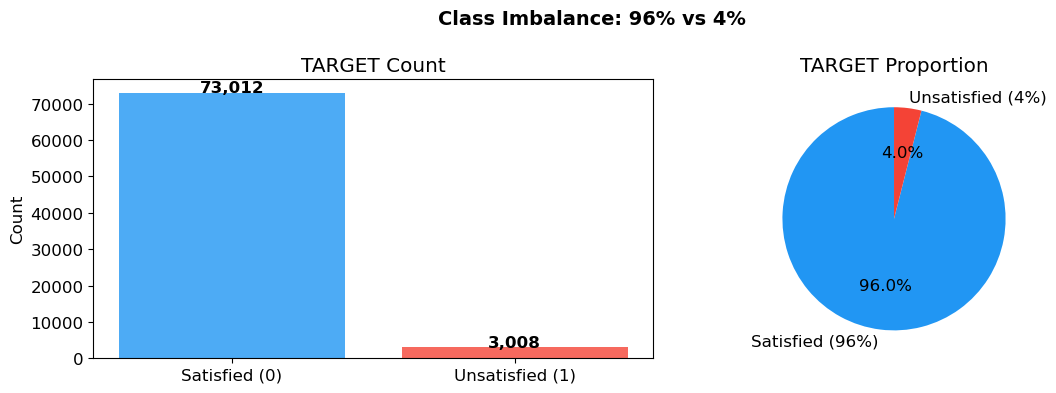


Imbalance ratio: 24.3:1 (Satisfied vs Unsatisfied)
Conclusion: class imbalance must be addressed (SMOTE or class_weight)


In [3]:
target_counts = train['TARGET'].value_counts()
target_pct    = train['TARGET'].value_counts(normalize=True)

print('TARGET distribution:')
print(pd.DataFrame({'count': target_counts, 'proportion': target_pct}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(['Satisfied (0)', 'Unsatisfied (1)'],
            target_counts.values,
            color=['#2196F3', '#F44336'], alpha=0.8)
axes[0].set_title('TARGET Count')
axes[0].set_ylabel('Count')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(target_counts.values,
            labels=['Satisfied (96%)', 'Unsatisfied (4%)'],
            colors=['#2196F3', '#F44336'],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('TARGET Proportion')

plt.suptitle('Class Imbalance: 96% vs 4%', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nImbalance ratio: {target_pct[0]/target_pct[1]:.1f}:1 (Satisfied vs Unsatisfied)')
print('Conclusion: class imbalance must be addressed (SMOTE or class_weight)')

## 3. Missing Values & Hidden Sentinel Values

In [4]:
# Real missing values
missing = train.isnull().sum()
print(f'Total real NaN missing values: {missing.sum()}')

# Hidden sentinel values (-999999 etc.)
special_values = [-999999, 9999999999, 99999999, -9999]
print('\n=== Hidden Sentinel Value Check ===')
for val in special_values:
    count = (train == val).sum().sum()
    if count > 0:
        affected_cols = (train == val).sum()
        affected_cols = affected_cols[affected_cols > 0]
        print(f'Value {val}: appears {count} times, affected columns: {list(affected_cols.index)}')

# Detailed check on var3
print('\n=== var3 Value Distribution (top 10) ===')
print(train['var3'].value_counts().head(10))
print(f'Count of -999999 in var3: {(train["var3"] == -999999).sum()}')

Total real NaN missing values: 0

=== Hidden Sentinel Value Check ===
Value -999999: appears 116 times, affected columns: ['var3']
Value 9999999999: appears 1194 times, affected columns: ['delta_imp_amort_var18_1y3', 'delta_imp_amort_var34_1y3', 'delta_imp_aport_var13_1y3', 'delta_imp_aport_var17_1y3', 'delta_imp_aport_var33_1y3', 'delta_imp_compra_var44_1y3', 'delta_imp_reemb_var13_1y3', 'delta_imp_reemb_var17_1y3', 'delta_imp_reemb_var33_1y3', 'delta_imp_trasp_var17_in_1y3', 'delta_imp_trasp_var17_out_1y3', 'delta_imp_trasp_var33_in_1y3', 'delta_imp_trasp_var33_out_1y3', 'delta_imp_venta_var44_1y3', 'delta_num_aport_var13_1y3', 'delta_num_aport_var17_1y3', 'delta_num_aport_var33_1y3', 'delta_num_compra_var44_1y3', 'delta_num_reemb_var13_1y3', 'delta_num_reemb_var17_1y3', 'delta_num_reemb_var33_1y3', 'delta_num_trasp_var17_in_1y3', 'delta_num_trasp_var17_out_1y3', 'delta_num_trasp_var33_in_1y3', 'delta_num_trasp_var33_out_1y3', 'delta_num_venta_var44_1y3']

=== var3 Value Distribution

## 4. Zero-Variance Features & Duplicate Columns — Removing Useless Features

In [5]:
features = [c for c in train.columns if c not in ['ID', 'TARGET']]

# Zero-variance features
zero_var_cols = [col for col in features if train[col].std() == 0]
print(f'Zero-variance feature count: {len(zero_var_cols)}')
print(f'Examples: {zero_var_cols[:5]}')

# Near-zero variance (std < 0.01)
near_zero_var = [col for col in features if 0 < train[col].std() < 0.01]
print(f'\nNear-zero variance feature count: {len(near_zero_var)}')

# Duplicate column check
print('\nChecking for duplicate columns (may take a moment)...')
duplicated_cols = set()
cols = features
for i in range(len(cols)):
    if cols[i] in duplicated_cols:
        continue
    for j in range(i+1, len(cols)):
        if cols[j] in duplicated_cols:
            continue
        if train[cols[i]].equals(train[cols[j]]):
            duplicated_cols.add(cols[j])

print(f'Duplicate column count: {len(duplicated_cols)}')

# Summary of removable columns
removable = set(zero_var_cols) | duplicated_cols
print(f'\nTotal features safe to remove: {len(removable)}')
print(f'Remaining features after cleanup: {len(features) - len(removable)}')

Zero-variance feature count: 34
Examples: ['ind_var2_0', 'ind_var2', 'ind_var27_0', 'ind_var28_0', 'ind_var28']

Near-zero variance feature count: 9

Checking for duplicate columns (may take a moment)...
Duplicate column count: 62

Total features safe to remove: 63
Remaining features after cleanup: 306


## 5. Sparsity Analysis — Zero-Dominated Columns

=== Zero-Value Ratio Distribution ===
Columns with >99% zeros: 220
Columns with >95% zeros: 283
Columns with >90% zeros: 307


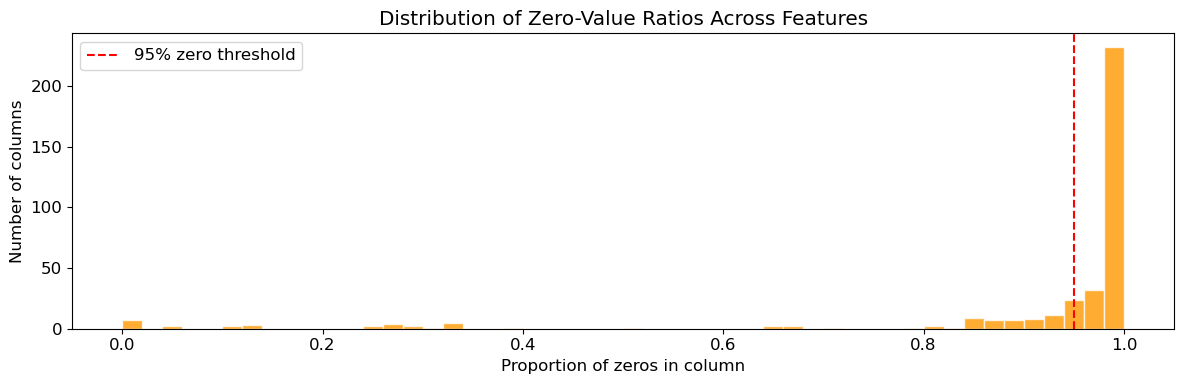


Conclusion: many features are extremely sparse. Consider dropping or creating binary is_active flags for modeling.


In [6]:
# Proportion of zeros per column
zero_ratio = (train[features] == 0).mean().sort_values(ascending=False)

print('=== Zero-Value Ratio Distribution ===')
print(f'Columns with >99% zeros: {(zero_ratio > 0.99).sum()}')
print(f'Columns with >95% zeros: {(zero_ratio > 0.95).sum()}')
print(f'Columns with >90% zeros: {(zero_ratio > 0.90).sum()}')

# Visualize zero ratio distribution
plt.figure(figsize=(12, 4))
plt.hist(zero_ratio.values, bins=50, color='#FF9800', alpha=0.8, edgecolor='white')
plt.axvline(x=0.95, color='red', linestyle='--', label='95% zero threshold')
plt.xlabel('Proportion of zeros in column')
plt.ylabel('Number of columns')
plt.title('Distribution of Zero-Value Ratios Across Features')
plt.legend()
plt.tight_layout()
plt.savefig('02_zero_ratio_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nConclusion: many features are extremely sparse. Consider dropping or creating binary is_active flags for modeling.')

## 6. Feature vs TARGET Relationship — Finding the Most Discriminative Features

Top 15 most discriminative features by mean difference:
delta_imp_aport_var13_1y3        2.990801e+07
delta_num_aport_var13_1y3        2.990801e+07
delta_num_venta_var44_1y3        5.752479e+06
delta_imp_venta_var44_1y3        5.752479e+06
delta_num_compra_var44_1y3       2.664601e+06
delta_imp_compra_var44_1y3       2.664601e+06
delta_num_aport_var17_1y3        1.880156e+06
delta_imp_aport_var17_1y3        1.880156e+06
delta_imp_reemb_var13_1y3        1.743192e+06
delta_num_reemb_var13_1y3        1.743192e+06
delta_imp_reemb_var17_1y3        7.221561e+05
delta_num_reemb_var17_1y3        7.221561e+05
delta_imp_trasp_var33_in_1y3     6.848189e+05
delta_num_trasp_var33_in_1y3     6.848189e+05
delta_num_trasp_var17_out_1y3    5.478551e+05
dtype: float64


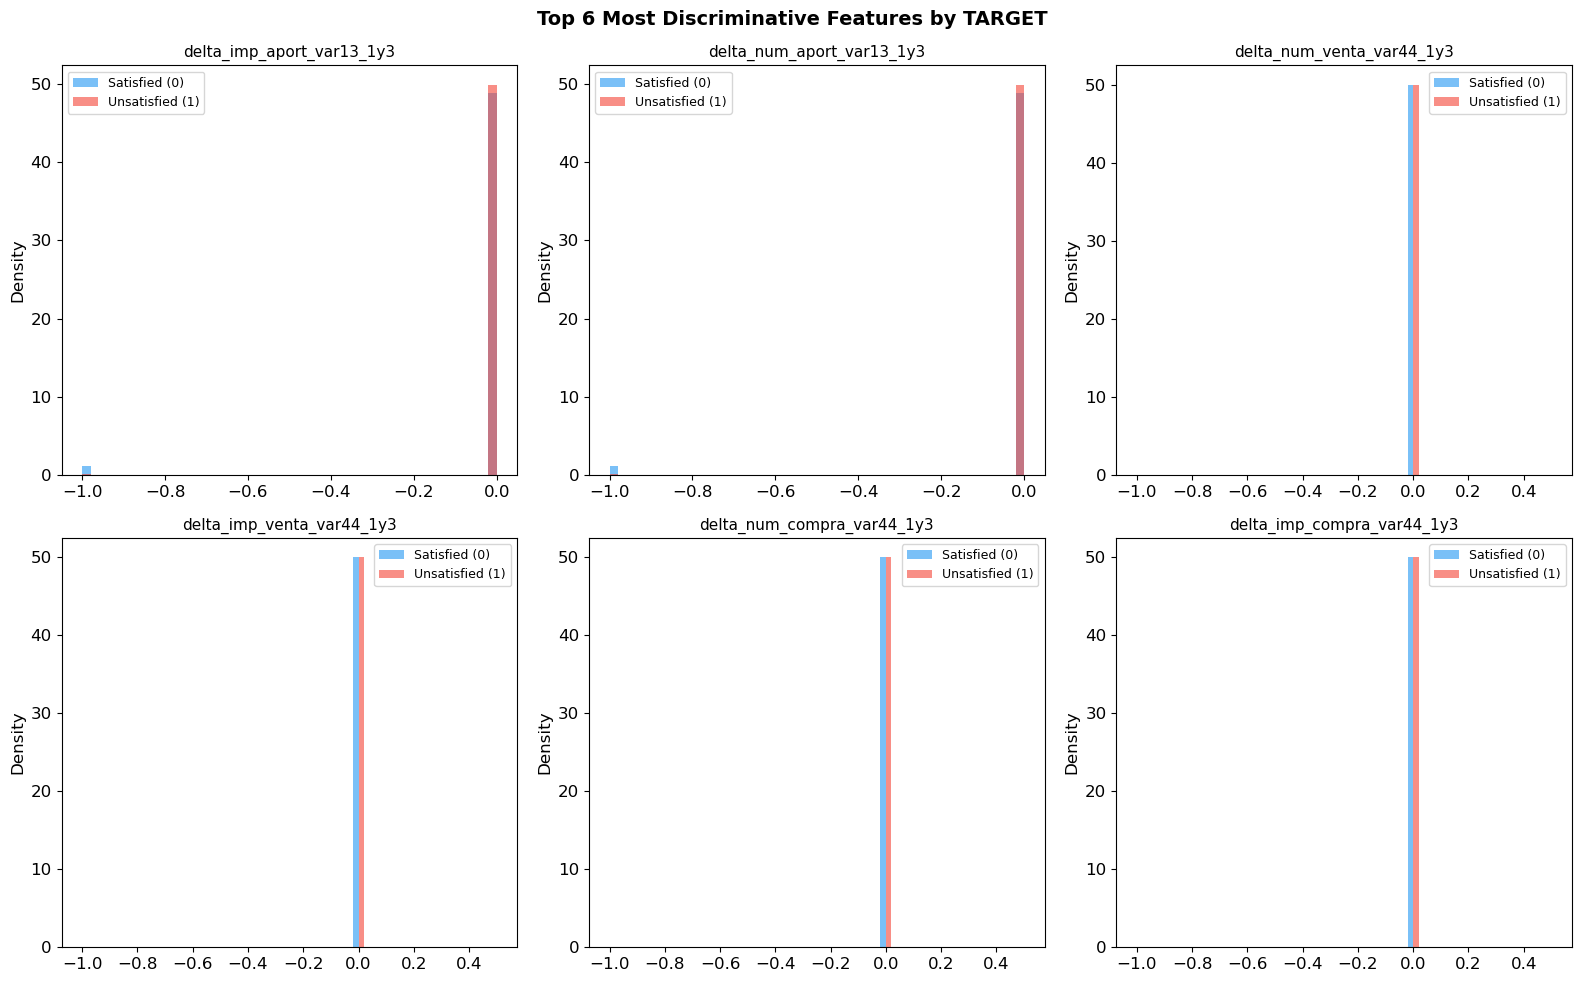

In [7]:
# Group by TARGET and compute mean difference per feature
clean_features = [c for c in features if c not in zero_var_cols]

group_means = train[clean_features + ['TARGET']].groupby('TARGET').mean()
mean_diff = (group_means.loc[1] - group_means.loc[0]).abs().sort_values(ascending=False)

top_features = mean_diff.head(15).index.tolist()
print('Top 15 most discriminative features by mean difference:')
print(mean_diff.head(15))

# Visualize distribution of top 6 features
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, feat in zip(axes.flat, top_features[:6]):
    satisfied   = train[train.TARGET == 0][feat]
    unsatisfied = train[train.TARGET == 1][feat]

    # Clip outliers for cleaner visualization
    p99 = satisfied.quantile(0.99)
    satisfied   = satisfied[satisfied <= p99]
    unsatisfied = unsatisfied[unsatisfied <= p99]

    ax.hist(satisfied,   bins=50, alpha=0.6, label='Satisfied (0)',   color='#2196F3', density=True)
    ax.hist(unsatisfied, bins=50, alpha=0.6, label='Unsatisfied (1)', color='#F44336', density=True)
    ax.set_title(feat, fontsize=11)
    ax.legend(fontsize=9)
    ax.set_ylabel('Density')

plt.suptitle('Top 6 Most Discriminative Features by TARGET', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('03_top_features_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Correlation Analysis — Identifying Redundant Features

Top 20 features most correlated with TARGET:
ind_var30              0.149811
num_meses_var5_ult3    0.148253
num_var30              0.138289
num_var42              0.135693
ind_var5               0.135349
num_var5               0.134095
var36                  0.102919
var15                  0.101322
num_var4               0.080194
num_var35              0.076872
ind_var8_0             0.046665
num_var8_0             0.046622
ind_var13              0.039612
ind_var13_0            0.039471
num_var13              0.038400
ind_var12_0            0.038215
num_var13_0            0.038045
saldo_var30            0.037092
ind_var39_0            0.035045
ind_var13_corto        0.034438
Name: TARGET, dtype: float64

Computing inter-feature correlations (may take a moment)...

Feature pairs with correlation > 0.95: 28
Examples: [('num_var5', 'ind_var5'), ('num_var35', 'num_var4'), ('num_var8_0', 'ind_var8_0'), ('ind_var13_0', 'ind_var13'), ('num_var13', 'ind_var13')]


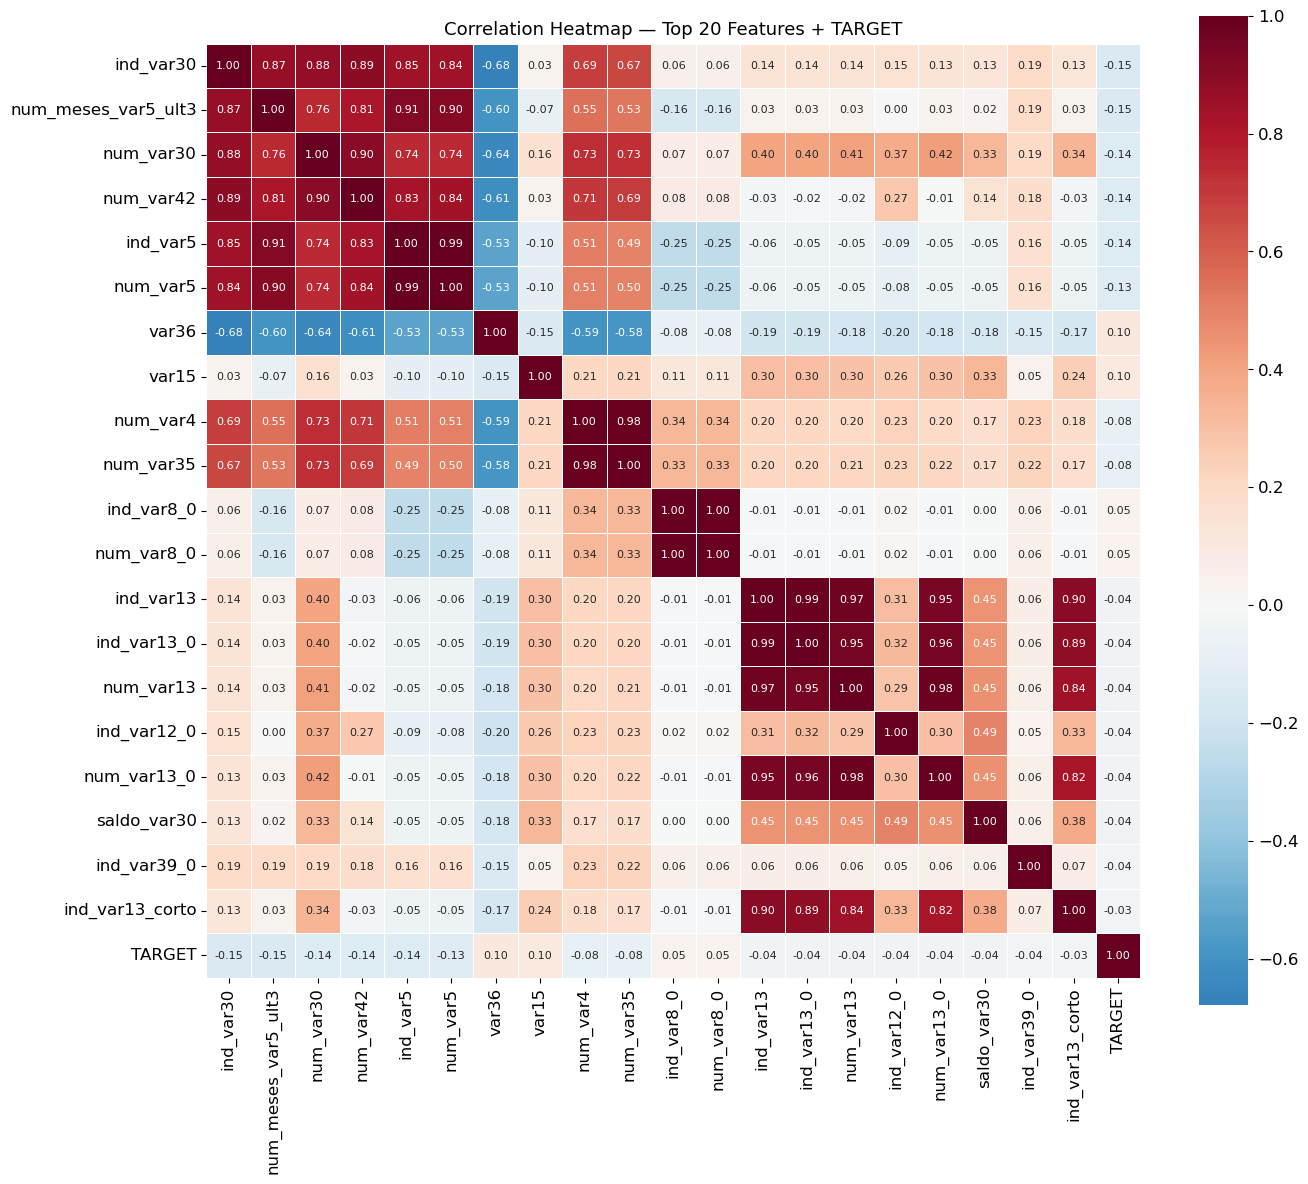

In [8]:
# Correlation with TARGET (absolute value)
target_corr = train[clean_features + ['TARGET']].corr()['TARGET'].abs()
target_corr = target_corr.drop('TARGET').sort_values(ascending=False)

print('Top 20 features most correlated with TARGET:')
print(target_corr.head(20))

# Highly correlated feature pairs (potentially redundant)
print('\nComputing inter-feature correlations (may take a moment)...')
top50_feats = target_corr.head(50).index.tolist()
corr_matrix = train[top50_feats].corr().abs()

# Find highly correlated pairs (> 0.95)
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = [(col, row) for col in upper_tri.columns
                   for row in upper_tri.index
                   if upper_tri.loc[row, col] > 0.95]
print(f'\nFeature pairs with correlation > 0.95: {len(high_corr_pairs)}')
if high_corr_pairs:
    print('Examples:', high_corr_pairs[:5])

# Heatmap (top 20 features)
top20 = target_corr.head(20).index.tolist()
plt.figure(figsize=(14, 12))
sns.heatmap(train[top20 + ['TARGET']].corr(),
            annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5,
            annot_kws={'size': 8})
plt.title('Correlation Heatmap — Top 20 Features + TARGET', fontsize=13)
plt.tight_layout()
plt.savefig('04_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Export Clean Datasets — Ready for Teammates

In [9]:
# Consolidate all columns to drop
cols_to_drop = list(removable)  # zero-variance + duplicate columns

# Handle var3 sentinel value
train_clean = train.copy()
test_clean  = test.copy()

# Replace -999999 with mode (computed from train only)
var3_mode = train_clean[train_clean['var3'] != -999999]['var3'].mode()[0]
train_clean['var3'] = train_clean['var3'].replace(-999999, var3_mode)
test_clean['var3']  = test_clean['var3'].replace(-999999, var3_mode)  # use train's mode

# Drop useless columns (preserve ID and TARGET)
cols_to_drop_filtered = [c for c in cols_to_drop if c in train_clean.columns and c not in ['ID', 'TARGET']]
train_clean = train_clean.drop(columns=cols_to_drop_filtered)
test_clean  = test_clean.drop(columns=[c for c in cols_to_drop_filtered if c in test_clean.columns])

# Save
train_clean.to_csv('train_clean.csv', index=False)
test_clean.to_csv('test_clean.csv',   index=False)

print('=== Cleanup Summary ===')
print(f'Original feature count : {len(features)}')
print(f'Features removed       : {len(cols_to_drop_filtered)}')
print(f'Features remaining     : {train_clean.shape[1] - 2}  (excluding ID/TARGET)')
print(f'\ntrain_clean shape: {train_clean.shape}')
print(f'test_clean  shape: {test_clean.shape}')
print('\nFiles saved: train_clean.csv, test_clean.csv')

=== Cleanup Summary ===
Original feature count : 369
Features removed       : 63
Features remaining     : 306  (excluding ID/TARGET)

train_clean shape: (76020, 308)
test_clean  shape: (75818, 307)

Files saved: train_clean.csv, test_clean.csv


## 9. EDA Summary

In [11]:
print('=' * 58)
print('         SANTANDER EDA — KEY FINDINGS SUMMARY')
print('=' * 58)
print(f'Dataset size          : {train.shape[0]:,} rows x {train.shape[1]} columns')
print(f'Class imbalance       : Satisfied 96% vs Unsatisfied 4%  -> must address')
print(f'Real missing values   : {missing.sum()} NaN')
print(f'Hidden sentinel values: var3 contained -999999  -> replaced with mode')
print(f'Zero-variance features: {len(zero_var_cols)}  -> removed')
print(f'Duplicate features    : {len(duplicated_cols)}  -> removed')
print(f'Sparse features(>95%0): {(zero_ratio > 0.95).sum()}  -> flag for modeling')
print(f'Top features          : {top_features[:3]}')


         SANTANDER EDA — KEY FINDINGS SUMMARY
Dataset size          : 76,020 rows x 371 columns
Class imbalance       : Satisfied 96% vs Unsatisfied 4%  -> must address
Real missing values   : 0 NaN
Hidden sentinel values: var3 contained -999999  -> replaced with mode
Zero-variance features: 34  -> removed
Duplicate features    : 62  -> removed
Sparse features(>95%0): 283  -> flag for modeling
Top features          : ['delta_imp_aport_var13_1y3', 'delta_num_aport_var13_1y3', 'delta_num_venta_var44_1y3']
